Introducción a las bases de la Astronomía Estelar
===

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
La astronomía es una Ciencia cuya fuente de información principal es la radiación que nos llega de las estrellas y demás objetos celestes. El objetivo de esta práctica es familiarizar al estudiante con los modelos más simples para describir la radiación estelar.

El cuerpo negro y sus aproximaciones
---
Un cuerpo negro es una entidad física ideal que absorbe toda la
radiación incidente, en todas las longitudes de onda y ángulos de
incidencia posibles. Hacia comienzos de 1900, hubieron varios intentos
de describir el espectro de radiación de un cuerpo negro, hasta que
Planck desarrolló la siguiente expresión:

\begin{equation}
%  B(\nu ,T) = \frac{2
  %    h\nu^{3}}{c^2}\frac{1}{e^{\frac{h\nu}{kT}}-1}\textnormal{.}
  B(\lambda ,T) = \frac{2 h c^{2}}{\lambda^{5}}\frac{1}{e^{\frac{h
        c}{\lambda kT}}-1}
\end{equation}

La cual describe la distribución espectral de la radiación de un
cuerpo negro, en equilibrio termodinámico, a una temperatura
$T$. Dónde $h$ y $k$ son las constantes de Planck y de Boltzmann,
respectivamente, y $c$ es la velocidad de la luz en el vacío.

La distribución de Planck, suele escribirse en terminos de $c_{1}$ y
$c_{2}$, como sigue:

\begin{equation}
  B(\lambda ,T) = \frac{c1}{\lambda^{5}}\frac{1}{e^{\frac{c2}{\lambda
        T}}-1}
\end{equation}

dónde $c_{1} = 2\,h\,c^{2}$ y $c_{2} = h c/k$. Por otro lado, aplicando la
conservación del flujo para todo el espectro, se puede transformar a
frecuencia ($\nu$),

\begin{equation}
B(\nu ,T) d\nu = -B(\lambda ,T) d\lambda
\end{equation}

teniendo en cuenta que: $d\nu = -c/\lambda^{2} d\lambda$.

Caracterización del cuerpo negro
---
El flujo irradiado por un cuerpo negro, por unidad de frecuencia, se
puede escribir de la siguiente forma:

\begin{equation}
 F(\nu) = \int B({\nu},T) \cos(\theta) d\Omega
\end{equation}

donde la integral se hace sobre el ángulo sólido $d\Omega$. Debido a
la isotropía del problema, se tiene $F(\nu)=\pi\ B(\nu,T)$. Luego,
integrando para todas las frecuencias se obtiene el flujo total
irradiado,

\begin{equation}
F = \int_{0}^{\infty} F(\nu) d\nu
\end{equation}

Por otro lado, el máximo de la distribución espectral de un cuerpo negro es inversamente proporcional a la temperatura. Esto se conoce como ley de desplazamiento de Wien,

\begin{equation}
\lambda_{\mathrm{max}} T = 0.28978~\mathrm{cm~K.}
\end{equation}

Referencias
---
* [Práctica 01 (overleaf)](https://www.overleaf.com/read/gwmxrtwffkxf)

---

Ejercicios
---

Objetivos:
* Graficar una función de planck para una temperatura determinada
* Integrar la función entre dos longitudes de onda dadas
* Evaluar las aproximaciones a la función de planck y graficarlas
* Usar la funcionalidad de manejo de unidades

**1.** Defina las funciones de Planck, Wien y Rayleigh-Jeans en la siguiente celda

In [8]:
import matplotlib.pyplot as plt
from astropy import units as u
import numpy as np

h = 6.62607015e-27 * u.erg*u.s
c = 29979245800.0  * u.cm/u.s
k = 1.380649e-16   * u.erg/u.K

c1 = 2.*h*c*c # Constantes usuales en la expresión de Planck
c2 = h*(c/k)

def B(x, T):    #Esta es la ecuación de Planck
    ''' El valor de x debe estar en AA y se pasa a cm para que se corresponda con las unidades definidas 
    de c1 y c2. El factor .to('erg / cm3 s') es para pasar las unidades en las que calcula python 
    originalmente la función [cm2 erg / cm5 s] a [erg / cm3 s]. '''
    xx=x.to('cm')
    result = (c1/np.power(xx,5))/(np.exp(c2/(xx*T))-1.)
    return result.to('erg / cm3 s')

def W(x, T):    #La ecuación de Wien
    xx=x.to('cm')
    result = (c1/np.power(xx,5))/np.exp(c2/(xx*T))
    return result.to('erg / cm3 s')

def R(x, T):    #La ecuación de Rayleigh-Jeans
    xx=x.to("cm")
    result = (c1/c2)*(T/np.power(xx,4))
    return result.to('erg / cm3 s')

Una vez hecho lo anterior, la siguiente celda grafica las tres funciones:

<IPython.core.display.Javascript object>


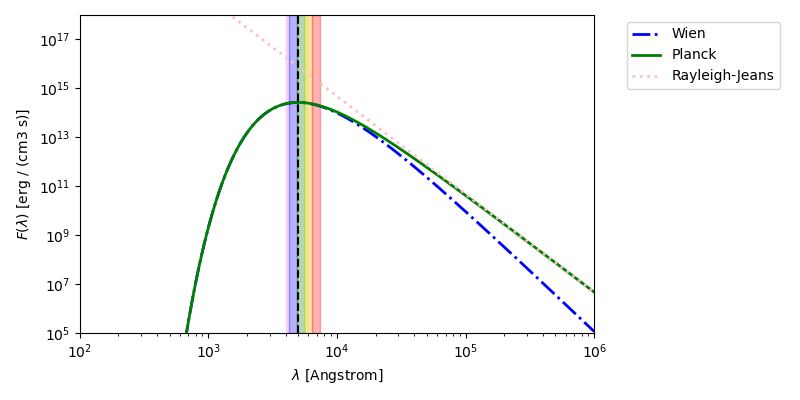

C:\Users\pedro_000\anaconda3\envs\AEpracticas\lib\site-packages\astropy\units\quantity.py:477: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
<ipython-input-12-12cb1ccba95c>:25: MatplotlibDeprecationWarning: The 'basex' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_xscale ( 'log', basex = 10 )
<ipython-input-12-12cb1ccba95c>:26: MatplotlibDeprecationWarning: The 'basey' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_yscale ( 'log', basey = 10 )
C:\Users\pedro_000\anaconda3\envs\AEpracticas\lib\site-packages\astropy\units\quantity.py:477: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [12]:
%matplotlib notebook
# Esto sirve para que el grafico sea interactivo. 
#  Si no funciona cambiarlo, cambiar:
# notebook -> inline

from astropy import constants as const # Es para que cargue el valor de const.b_wien

wav = np.arange(1E1, 1E6) * u.AA

T = 5800 * u.K # Defino la Temperatura en K

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )

ax.axvspan ( 4000, 4250, alpha = 0.3, color = 'violet' ) # banda vertical
ax.axvspan ( 4250, 4900, alpha = 0.3, color = 'blue' )
ax.axvspan ( 4900, 5600, alpha = 0.3, color = 'green' )
ax.axvspan ( 5600, 5850, alpha = 0.3, color = 'yellow' )
ax.axvspan ( 5850, 6400, alpha = 0.3, color = 'orange' )
ax.axvspan ( 6400, 7400, alpha = 0.3, color = 'red' )
ax.set_ylim ( 1E5, 1E18 )
ax.set_xlim ( 1E2, 1E6 )

ax.set_xlabel ( r"$\lambda$ [{}]".format(wav.unit) )
ax.set_ylabel ( r"$F(\lambda)$ [{}]".format(B(wav,T).unit) )
ax.set_xscale ( 'log', basex = 10 )
ax.set_yscale ( 'log', basey = 10 )

ax.plot ( wav, W(wav,T), color = "blue", linewidth = 2, linestyle = '-.', label = 'Wien' )
ax.plot ( wav, B(wav,T), color = "green", linewidth = 2, linestyle = '-', label = 'Planck' )
ax.plot ( wav, R(wav,T), color = "pink", linewidth = 2, linestyle = ':', label = 'Rayleigh-Jeans' )

ax.axvline ( wavemax.value, color = "black", linestyle = '--' ) # el .value le saca las unidades.

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout() # Se usa esta forma de mostrar el grafico para que la _legend_ no quede cortada.
plt.show()

In [13]:
T=5778 *u.K
wavemax = (const.b_wien / T).to(u.AA)  # Wien's displacement law

print ( "[*] Long. de onda para el máximo de la distribución: ", wavemax )

[*] Long. de onda para el máximo de la distribución:  5015.181646218713 Angstrom


**2.** La diferencia porcentual, estara dada por la diferencia de cada función respecto a la función de planck.

In [14]:
# Función auxiliar para el grafico siguiente
def visible(a):
    a.axvspan ( 4000, 4250, alpha = 0.3, color = 'violet' ) 
    a.axvspan ( 4250, 4900, alpha = 0.3, color = 'blue' )
    a.axvspan ( 4900, 5600, alpha = 0.3, color = 'green' )
    a.axvspan ( 5600, 5850, alpha = 0.3, color = 'yellow' )
    a.axvspan ( 5850, 6400, alpha = 0.3, color = 'orange' )
    a.axvspan ( 6400, 7400, alpha = 0.3, color = 'red' )

In [15]:
#con esto simplemente veo qué es. Lo mismo en la celda de abajo
wav

<Quantity [1.00000e+01, 1.10000e+01, 1.20000e+01, ..., 9.99997e+05,
           9.99998e+05, 9.99999e+05] Angstrom>

In [16]:
comparacion(wav,30000 * u.K)

NameError: name 'comparacion' is not defined

<ipython-input-24-ac6bfbc8610c>:12: MatplotlibDeprecationWarning: The 'basex' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_xscale ( 'log', basex = 10 )
C:\Users\pedro_000\anaconda3\envs\AEpracticas\lib\site-packages\astropy\units\quantity.py:477: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
C:\Users\pedro_000\anaconda3\envs\AEpracticas\lib\site-packages\astropy\units\quantity.py:477: RuntimeWarning: invalid value encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


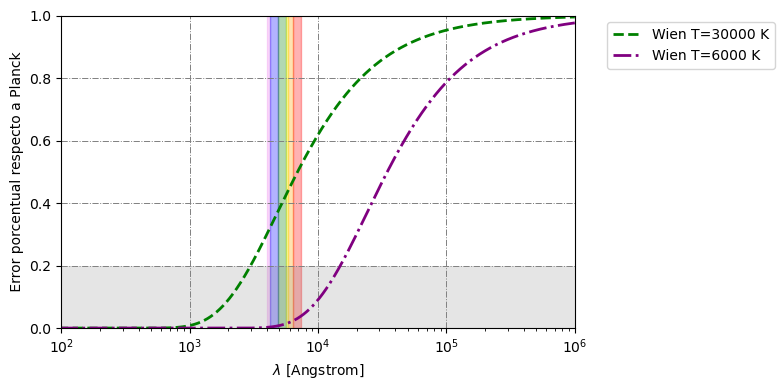

In [24]:
%matplotlib inline 

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )

visible(ax) # banda vertical

ax.set_ylim ( 0., 1 )
ax.set_xlim(1E2, 1E6)

ax.set_xlabel ( r"$\lambda$ [{}]".format(wav.unit) )
ax.set_ylabel ( " Error porcentual respecto a Planck " )
ax.set_xscale ( 'log', basex = 10 )

wav = np.arange ( 1E1, 1E6 ) * u.AA
#T = 30000 * u.K 

# Se puede generar una función que describa la diferencia porcentual
#  y devolver mediante el _return_ el valor del eje _y_ del siguiente grafico.
def comparacion(x, T):
    return (abs(W(wav,T)-B(wav,T)))/B(wav,T)

#ax.plot ( wav, comparacion(wav), color = "green", linewidth = 2, linestyle = '--', 
#         label = 'Wien T=%i K' %T.value )
ax.plot ( wav, comparacion(wav, 30000 * u.K), color = "green", linewidth = 2, linestyle = '--', 
         label = 'Wien T=30000 K')
ax.plot ( wav, comparacion(wav, 6000 * u.K), color = "purple", linewidth = 2, linestyle = '-.', 
         label = 'Wien T=6000 K')

ax.grid ( color = 'gray', linestyle = '-.', linewidth = 0.7 ) # Grafica la grilla
ax.axhspan ( 0, 0.2, facecolor = "gray", alpha = 0.2 ) # banda horizontal entre y=0 e y=0.2

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout() # Se usa esta forma de mostrar el grafico para que la _legend_ no quede cortada.
plt.show()

<ipython-input-19-30d6d8c14df4>:12: MatplotlibDeprecationWarning: The 'basex' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_xscale ( 'log', basex = 10 )
C:\Users\pedro_000\anaconda3\envs\AEpracticas\lib\site-packages\astropy\units\quantity.py:477: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
C:\Users\pedro_000\anaconda3\envs\AEpracticas\lib\site-packages\astropy\units\quantity.py:477: RuntimeWarning: divide by zero encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


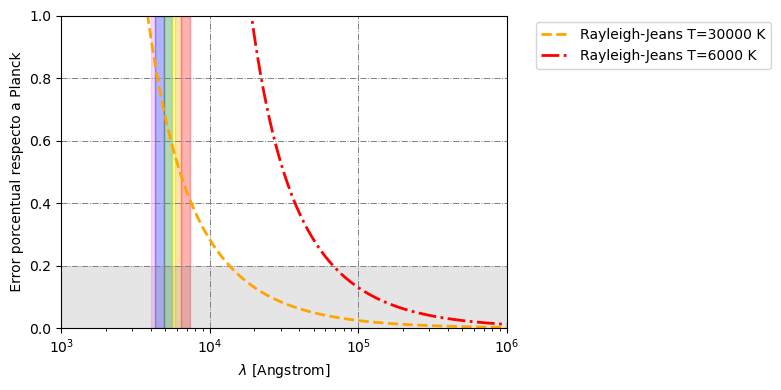

In [19]:
%matplotlib inline 

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )

visible(ax) # banda vertical

ax.set_ylim ( 0., 1 )
ax.set_xlim(1E3, 1E6)

ax.set_xlabel ( r"$\lambda$ [{}]".format(wav.unit) )
ax.set_ylabel ( " Error porcentual respecto a Planck " )
ax.set_xscale ( 'log', basex = 10 )

wav = np.arange ( 1E1, 1E6 ) * u.AA
#T = 30000 * u.K 

# Se puede generar una función que describa la diferencia porcentual
#  y devolver mediante el _return_ el valor del eje _y_ del siguiente grafico.
def comparacion1(x, T):
    return (abs(R(wav,T)-B(wav,T)))/B(wav,T)

ax.plot ( wav, comparacion1(wav, 30000 * u.K), color = "orange", linewidth = 2, linestyle = '--', 
         label = 'Rayleigh-Jeans T=30000 K')
ax.plot ( wav, comparacion1(wav, 6000 * u.K), color = "red", linewidth = 2, linestyle = '-.', 
         label = 'Rayleigh-Jeans T=6000 K')

ax.grid ( color = 'gray', linestyle = '-.', linewidth = 0.7 ) # Grafica la grilla
ax.axhspan ( 0, 0.2, facecolor = "gray", alpha = 0.2 ) # banda horizontal entre y=0 e y=0.2

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout() # Se usa esta forma de mostrar el grafico para que la _legend_ no quede cortada.
plt.show()

**3.** Cómo integrar una función

In [4]:
# Antes de hacer la integral, deduzca la expresión de la constante de boltzmann
#  en función de c1 y c2.

sigma = np.pi**5 / (120*(h*c**2)**3) * (c1/c2)**4
print (sigma)

5.6703744191844266e-05 erg / (cm2 K4 s)


In [84]:
from scipy.integrate import quad

# Redefino la funcion para no usar unidades y multiplico por pi por la integral
# en el angulo sólido
def bb(x):
    ''' Redefino la función para que tome la long. de onda en AA 
    y con el .value le saco las unidades para poder hacer la integral.
    Además, le agrego el pi para que represente el Flujo integrado.'''
    return np.pi * B(x * u.AA, Temp).value

Temp = 2000 * u.K

# Recuerde que para calcular la integral entre 4000 y 7000AA se puede usar 
#  la función interna de python _quad_.
int, err = quad ( bb, 4000, 7000 )
print ('el flujo para la estrella de', Temp, 'en el visible es de', int)

#Para calcular el flujo en todo el espectro puedo recurrir a estas dos opciones:

SB=sigma*Temp**4 * 1E8 #El término 1E8 corrige las unidades
#-> No entiendo dónde está la diferencia en las unidades entre un procedimiento y el otro
print ('el flujo total de la misma en todo el espectro es de', SB)

int2, err2= quad (bb,0,np.inf)
print ('O bien, numéricamente calculado', int2)

print ('La proporción de flujo en el visual respecto del total para la estrella de T=', Temp,'es de', int/SB)

# Y para el Flujo total tiene la Ley de Boltzmann. En este caso, tener en cuenta
#  las unidades (lineales) del diferencial de long. de onda.

el flujo para la estrella de 2000.0 K en el visible es de 705299706141129.8
el flujo total de la misma en todo el espectro es de 9.072599070695083e+16 erg / (cm2 s)
O bien, numéricamente calculado 2.7733040805923558e-42
La proporción de flujo en el visual respecto del total para la estrella de T= 2000.0 K es de 0.007773954306206262 cm2 s / erg


La longitud de onda del máximo de emisión es de  𝜆= 724.4429887962931 Angstrom +- 36.22214943981464


<ipython-input-81-d6d94cb7cf65>:27: MatplotlibDeprecationWarning: The 'basex' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_xscale ( 'log', basex = 10 )
<ipython-input-81-d6d94cb7cf65>:28: MatplotlibDeprecationWarning: The 'basey' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  ax.set_yscale ( 'log', basey = 10 )


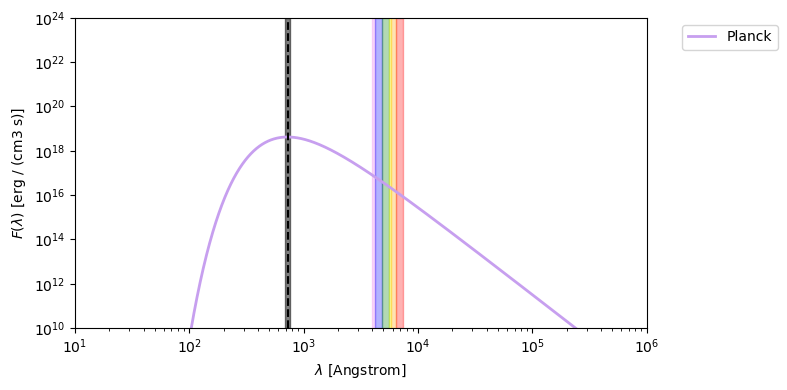

In [81]:
%matplotlib inline
# Esto sirve para que el grafico sea interactivo. 
#  Si no funciona cambiarlo, cambiar:
# notebook -> inline

from astropy import constants as const # Es para que cargue el valor de const.b_wien
wavemax = (const.b_wien / Temp).to(u.AA)
a=wavemax.value*0.95
b=wavemax.value*1.05
print ('La longitud de onda del máximo de emisión es de  𝜆=', wavemax, '+-', b-wavemax.value)
wav = np.arange(1E1, 1E6) * u.AA

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )

ax.axvspan ( 4000, 4250, alpha = 0.3, color = 'violet' ) # banda vertical
ax.axvspan ( 4250, 4900, alpha = 0.3, color = 'blue' )
ax.axvspan ( 4900, 5600, alpha = 0.3, color = 'green' )
ax.axvspan ( 5600, 5850, alpha = 0.3, color = 'yellow' )
ax.axvspan ( 5850, 6400, alpha = 0.3, color = 'orange' )
ax.axvspan ( 6400, 7400, alpha = 0.3, color = 'red' )
ax.axvspan (a, b , alpha = 0.5 , color = 'black')
ax.set_ylim ( 1E10, 1E24 )
ax.set_xlim ( 1E1, 1E6 )

ax.set_xlabel ( r"$\lambda$ [{}]".format(wav.unit) )
ax.set_ylabel ( r"$F(\lambda)$ [{}]".format(B(wav,Temp).unit) )
ax.set_xscale ( 'log', basex = 10 )
ax.set_yscale ( 'log', basey = 10 )

ax.plot ( wav, B(wav,Temp), color = "#C79FEF", linewidth = 2, linestyle = '-', label = 'Planck' )

ax.axvline ( wavemax.value, color = "black", linestyle = '--' ) # el .value le saca las unidades.

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout() # Se usa esta forma de mostrar el grafico para que la _legend_ no quede cortada.
plt.show()